# 📊 EDA — SRDB Equations Dataset (V5)

**File:** `srdb-equations-V5.csv`  
**Rows:** 3,318 | **Columns:** 26  
**Description:** Temperature-sensitivity models and Q10 values for soil respiration. Contains model parameters, R² values, and temperature sensitivity metrics across different temperature ranges.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Load Data


In [2]:
from pathlib import Path
raw = Path('../data/raw')
df = pd.read_csv(raw / 'srdb-equations-V5.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (3318, 26)


,Record_number,Model_type,Temp_effect,Model_output_units,Model_temp_min,Model_temp_max,Model_N,Model_R2,T_depth,Model_paramA,...,Q10_0_10,Q10_5_15,Q10_10_20,Q10_0_20,Q10_other1,Q10_other1_temp_min,Q10_other1_temp_max,Q10_other2,Q10_other2_temp_min,Q10_other2_temp_max
0,1.0,"Arrhenius, R=a exp(-b/c(T-d)), T in K",Positive,umol CO2/m2/s,3.0,22.0,80.0,0.82,2.0,17.45,...,3.74,2.54,2.00,2.74,1.5,5.0,15.0,1.3,15.0,25.0
1,2.0,"Arrhenius, R=a exp(-b/c(T-d)), T in K",Positive,umol CO2/m2/s,3.0,22.0,53.0,0.75,2.0,9.79,...,2.74,2.04,1.70,2.16,1.5,5.0,15.0,1.3,15.0,25.0
2,3.0,"Arrhenius, R=a exp(-b/c(T-d)), T in K",Positive,umol CO2/m2/s,3.0,22.0,82.0,0.84,2.0,7.00,...,2.18,1.73,1.51,1.81,1.5,5.0,15.0,1.3,15.0,25.0
3,4.0,"Arrhenius, R=a exp(-b/c(T-d)), T in K",Positive,umol CO2/m2/s,3.0,22.0,67.0,0.80,2.0,19.04,...,3.09,2.22,1.81,2.36,1.5,5.0,15.0,1.3,15.0,25.0
4,5.0,"Arrhenius, R=a exp(-b/c(T-d)), T in K",Positive,umol CO2/m2/s,3.0,22.0,96.0,0.91,2.0,24.75,...,3.33,2.34,1.88,2.50,1.5,5.0,15.0,1.3,15.0,25.0


## 2. Basic Information


In [3]:
df.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3318 entries, 0 to 3317
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Record_number        3318 non-null   float64
 1   Model_type           3318 non-null   object 
 2   Temp_effect          2841 non-null   object 
 3   Model_output_units   3004 non-null   object 
 4   Model_temp_min       2458 non-null   float64
 5   Model_temp_max       2458 non-null   float64
 6   Model_N              553 non-null    float64
 7   Model_R2             2429 non-null   float64
 8   T_depth              2723 non-null   float64
 9   Model_paramA         2385 non-null   float64
 10  Model_paramB         2390 non-null   float64
 11  Model_paramC         2338 non-null   float64
 12  Model_paramD         229 non-null    float64
 13  Model_paramE         30 non-null     float64
 14  WC_effect            1425 non-null   object 
 15  R10                  2122 non-null   f

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Record_number,3318.0,NaN,NaN,NaN,3536.224623,2240.106556,1.0,1432.5,3566.5,5521.75,7372.0
Model_type,3318,37,"Exponential, R=a exp(b(T-c))",1813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temp_effect,2841,3,Positive,2757,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model_output_units,3004,27,umol CO2/m2/s,1740,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model_temp_min,2458.0,NaN,NaN,NaN,3.559976,6.399849,-22.0,0.0,3.0,6.0,27.0
Model_temp_max,2458.0,NaN,NaN,NaN,23.543043,6.518432,0.0,19.0,23.0,28.0,54.0
Model_N,553.0,NaN,NaN,NaN,195.076817,893.290241,1.87,19.0,38.0,111.0,10090.0
Model_R2,2429.0,NaN,NaN,NaN,0.647599,0.221132,0.0,0.502,0.7,0.82,1.0
T_depth,2723.0,NaN,NaN,NaN,2.909365,28.621839,-200.0,5.0,5.0,10.0,50.0
Model_paramA,2385.0,NaN,NaN,NaN,3911375471699563.5,70690204894823000.0,-1134.1,0.322,0.859,4.77,2180000000000000000.0


## 3. Missing Values


Total missing: 43,799
                     Count  Percent
Q10_other2            3302    99.52
Q10_other2_temp_max   3302    99.52
Q10_other2_temp_min   3302    99.52
Model_paramE          3288    99.10
Model_paramD          3089    93.10
Model_N               2765    83.33
Q10_other1            2593    78.15
Q10_other1_temp_max   2577    77.67
Q10_other1_temp_min   2577    77.67
Q10_0_20              2277    68.63
Q10_0_10              1951    58.80
WC_effect             1893    57.05
Q10_5_15              1467    44.21
Q10_10_20             1384    41.71
R10                   1196    36.05
Model_paramC           980    29.54
Model_paramA           933    28.12
Model_paramB           928    27.97
Model_R2               889    26.79
Model_temp_max         860    25.92
Model_temp_min         860    25.92
T_depth                595    17.93
Temp_effect            477    14.38
Model_output_units     314     9.46
Record_number            0     0.00
Model_type               0     0.00


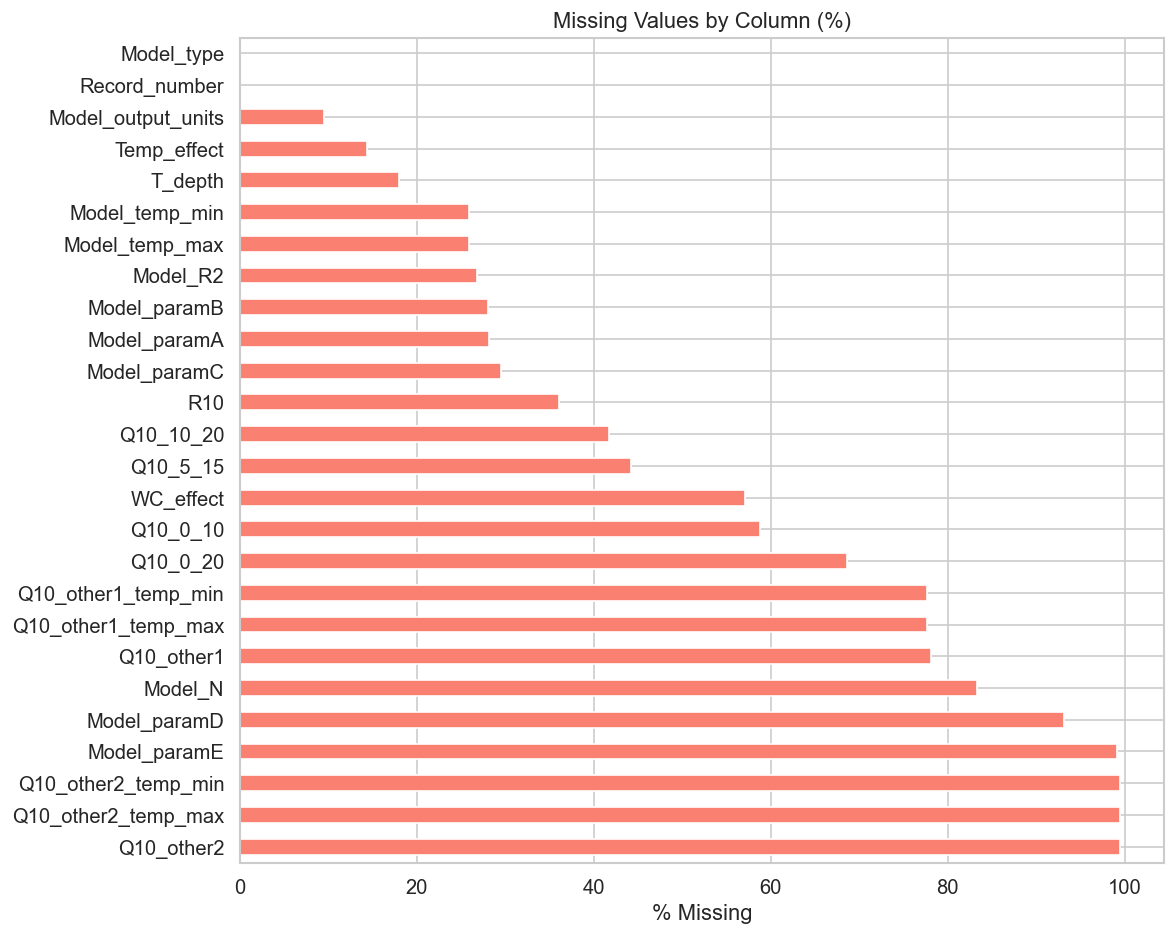

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct}).sort_values('Percent', ascending=False)
print(f"Total missing: {missing.sum():,}")
print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
missing_df['Percent'].plot(kind='barh', ax=ax, color='salmon')
ax.set_title('Missing Values by Column (%)')
ax.set_xlabel('% Missing')
plt.tight_layout()
plt.show()


## 4. Model Type Analysis


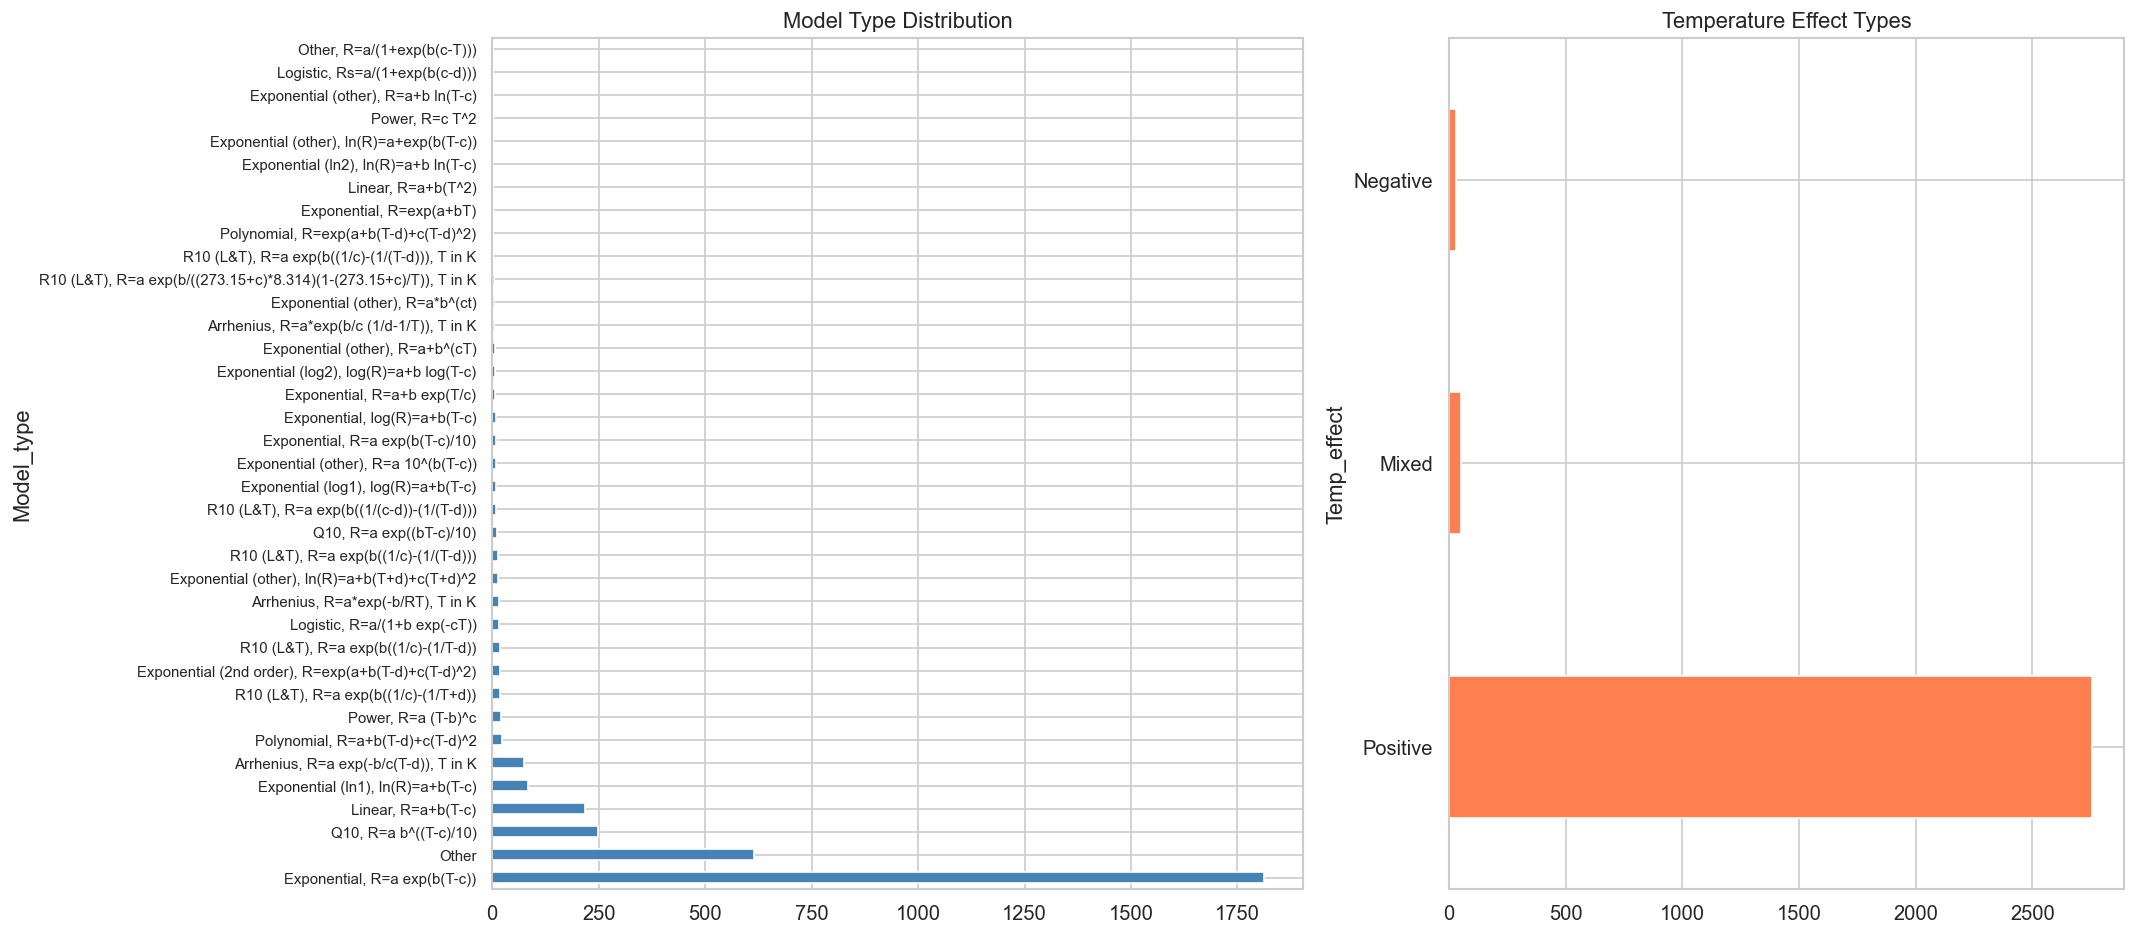

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1.2, 1]})

df['Model_type'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Model Type Distribution')
axes[0].tick_params(axis='y', labelsize=9)

df['Temp_effect'].value_counts().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Temperature Effect Types')

plt.tight_layout()
plt.show()


## 5. Model Quality — R² Distribution


Model R² stats (n=2429):
count    2429.000000
mean        0.647599
std         0.221132
min         0.000000
25%         0.502000
50%         0.700000
75%         0.820000
max         1.000000
Name: Model_R2, dtype: float64


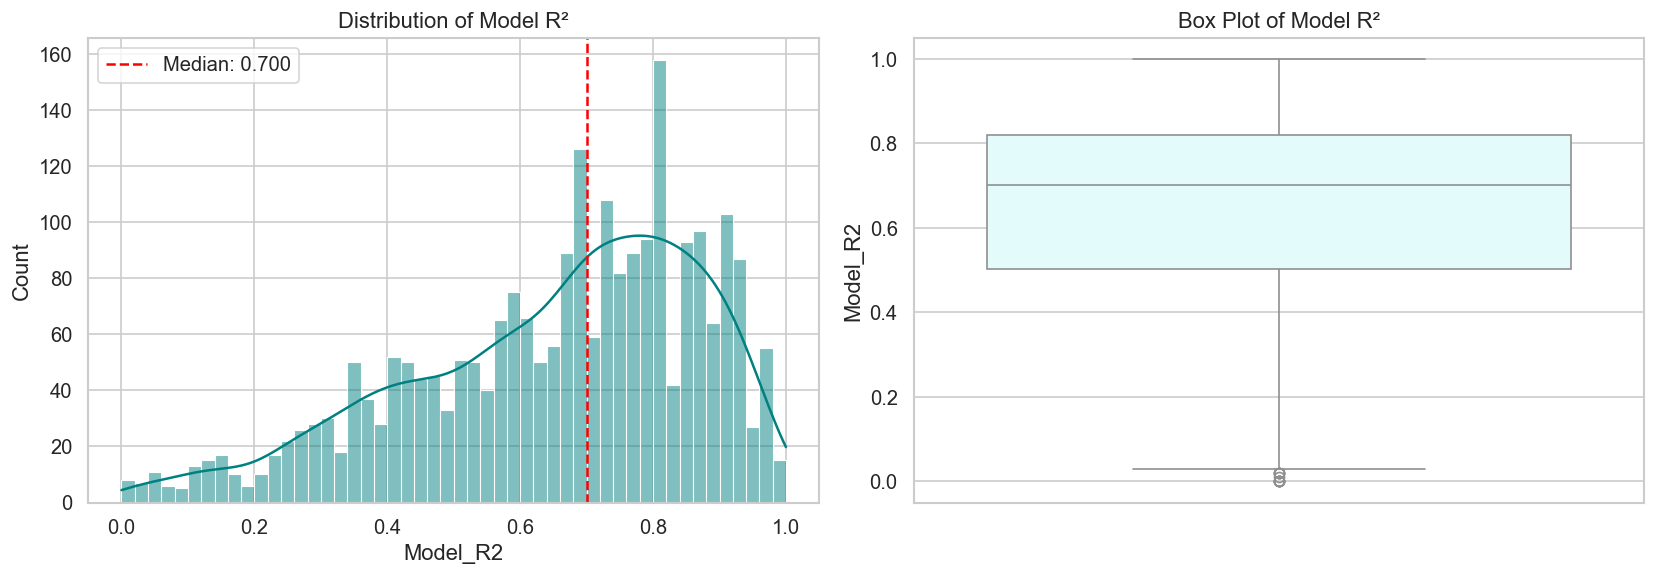

In [7]:
r2 = df['Model_R2'].dropna()
print(f"Model R² stats (n={len(r2)}):")
print(r2.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(r2, bins=50, ax=axes[0], color='teal', kde=True)
axes[0].set_title('Distribution of Model R²')
axes[0].axvline(r2.median(), color='red', ls='--', label=f'Median: {r2.median():.3f}')
axes[0].legend()

sns.boxplot(y=r2, ax=axes[1], color='lightcyan')
axes[1].set_title('Box Plot of Model R²')

plt.tight_layout()
plt.show()


## 6. Q10 Values Analysis

Q10 = factor by which respiration increases for a 10°C temperature rise.


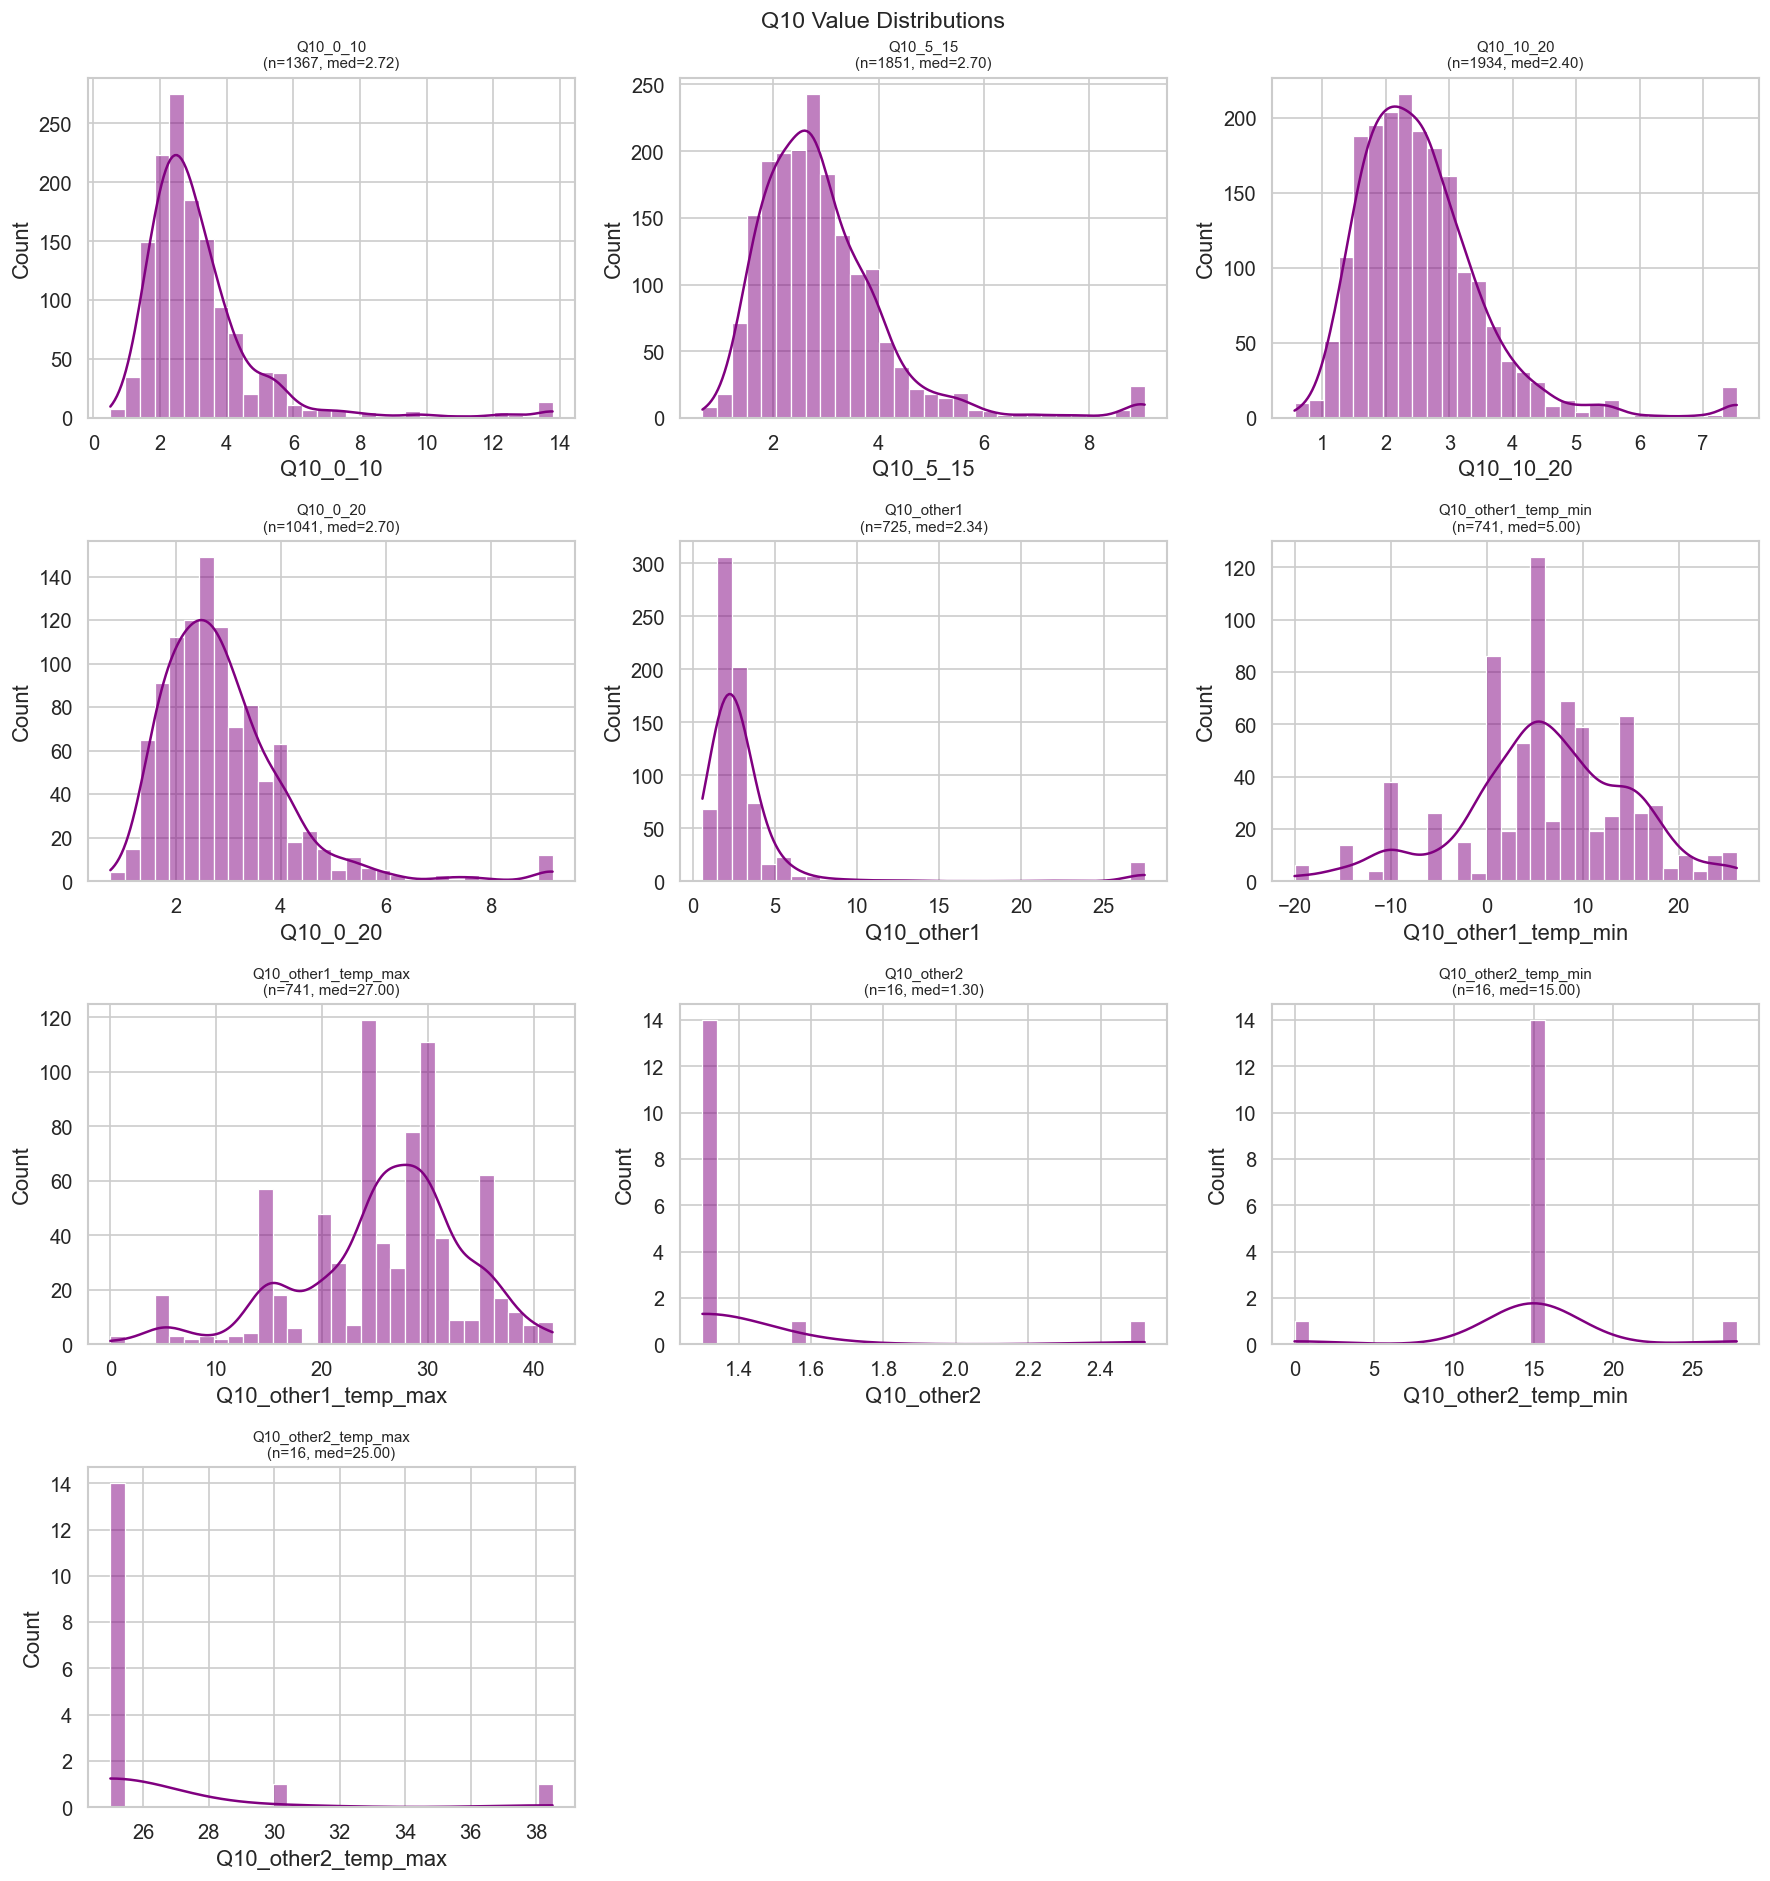

In [12]:
q10_cols = [c for c in df.columns if c.startswith('Q10')]

n_cols = min(3, len(q10_cols))  # use 2-3 plots per row depending on availability
n_rows = int(np.ceil(len(q10_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(q10_cols):
    data = df[col].dropna()
    if len(data) > 0:
        sns.histplot(data.clip(upper=data.quantile(0.99)), bins=30, ax=axes[i], color='purple', kde=True)
        axes[i].set_title(f'{col}\n(n={len(data)}, med={data.median():.2f})', fontsize=9)

# Hide any unused subplot slots in the final row
for j in range(len(q10_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q10 Value Distributions', fontsize=14)
plt.tight_layout()
plt.show()


## 7. Temperature Range of Models


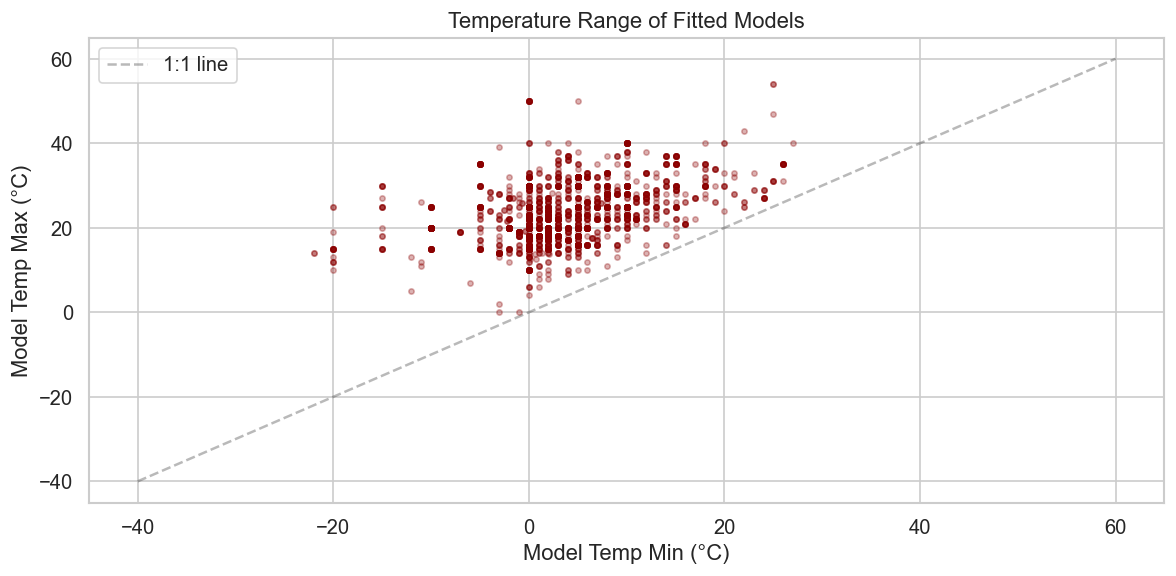

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
mask = df[['Model_temp_min', 'Model_temp_max']].notna().all(axis=1)
subset = df[mask]
ax.scatter(subset['Model_temp_min'], subset['Model_temp_max'], alpha=0.3, s=10, c='darkred')
ax.plot([-40, 60], [-40, 60], 'k--', alpha=0.3, label='1:1 line')
ax.set_xlabel('Model Temp Min (°C)')
ax.set_ylabel('Model Temp Max (°C)')
ax.set_title('Temperature Range of Fitted Models')
ax.legend()
plt.tight_layout()
plt.show()


## 8. R10 (Respiration at 10°C)


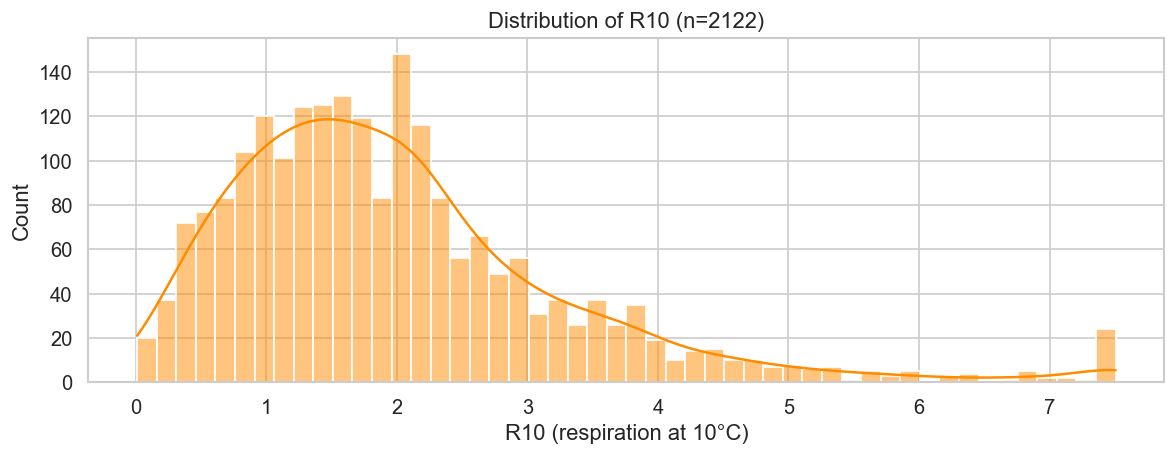

In [10]:
r10 = df['R10'].dropna()
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(r10.clip(upper=r10.quantile(0.99)), bins=50, color='darkorange', kde=True, ax=ax)
ax.set_title(f'Distribution of R10 (n={len(r10)})')
ax.set_xlabel('R10 (respiration at 10°C)')
plt.tight_layout()
plt.show()


## 9. Key Findings & Summary

### Dataset Summary
- **3,318 rows × 26 columns** — linked to main SRDB data via `Record_number`
- Contains fitted model parameters (A–E), R², Q10 values, and temperature ranges

### Key Observations
1. **Model types**: Multiple equation forms used to describe temperature sensitivity
2. **R² quality**: Median R² around 0.7–0.8 — models generally fit well
3. **Q10 values**: Typically 1.5–3.0 (expected range for soil respiration)
4. **Missing data**: Model_paramD/E and Q10_other2 have extreme missingness (>90%)
5. **R10**: Right-skewed, representing baseline respiration rates

### Action Plan
- Join with SRDB data on `Record_number` for integrated analysis
- Filter by Model_R2 > 0.5 for quality models
- Use Q10_5_15 or Q10_10_20 as primary temperature sensitivity metrics
